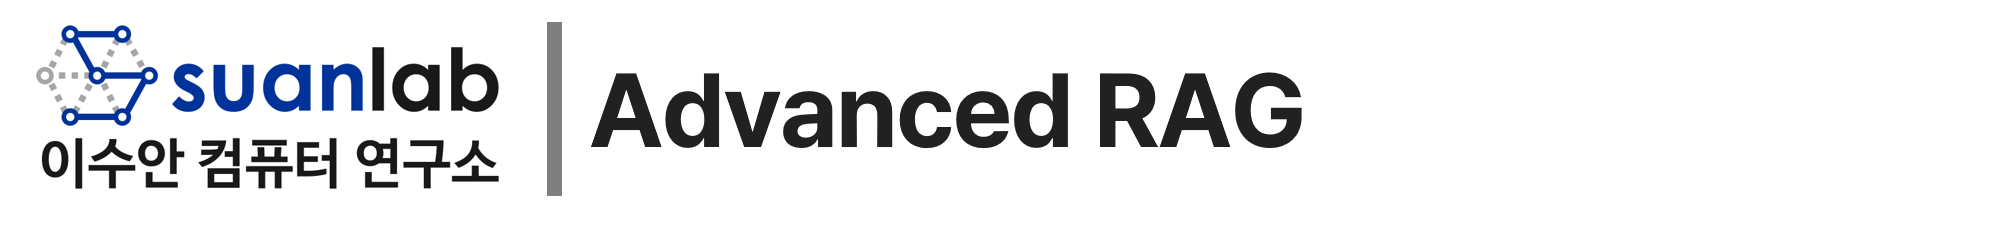

# 🎯 Reranking — Cross-Encoder 2단계 검색


## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공).
!pip install -q "anthropic>=0.40" rank_bm25 faiss-cpu sentence-transformers

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 57.2 MB/s eta 0:00:00
Anthropic API Key: ··········
환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨


In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


# Cross-Encoder Reranking (2단계 검색)

## 학습목표
- 1단계 Hybrid 검색으로 **넓게**(top-N) 뽑고, cross-encoder로 **정밀하게**(top-k) 재정렬
- 리랭크 전/후 nDCG·MRR을 비교해 2단계 검색의 효과를 확인

## 사전개념
- **Bi-encoder**(임베딩): 질문/문서를 독립 인코딩 → 빠르지만 거칠다(recall용)
- **Cross-encoder**: 질문+문서를 함께 인코딩 → 느리지만 정밀(precision용)
- 전략: recall(많이) → precision(정확히)의 2단계

> lab3 Hybrid 결과를 입력으로 재사용 (셋업 최소화)
> 비-Claude: sentence-transformers CrossEncoder(리랭킹, Claude 미제공)

## 용어 미니 사전 (리랭킹 편)
검색을 **2단계**로: 먼저 넓게 후보를 뽑고(recall), 그 다음 정밀하게 다시 줄세움(precision)

| 용어 | 한 줄 뜻 |
|---|---|
| **Bi-encoder(임베딩 검색)** | 질문·문서를 *따로* 숫자화해 비교. 빠르지만 거침 → 1차 후보용 |
| **Cross-encoder(리랭커)** | 질문+문서를 *함께* 보고 관련도 채점. 느리지만 정밀 → 2차 정렬용 |
| **Reranking(재정렬)** | 1차 후보를 더 정밀한 모델로 다시 순서 매기는 것 |
| **top-N / top-k** | 1차로 넓게 N개 뽑고, 2차로 정밀하게 k개만 남김 |
| **Claude-rerank** | Claude에게 후보들의 관련도를 점수 매기게 하는 LLM 리랭커(근거 설명 가능, 비쌈) |
| **latency(지연)** | 한 질문 처리에 걸리는 시간(ms). 정밀할수록 보통 느려짐 |
| **MRR / nDCG** | 정답을 *위쪽*에 둘수록 높아지는 순위 품질 점수 |

> 핵심 메시지: **넓게 뽑고(recall) → 정밀하게 좁힌다(precision)**   
단, 1차에서 정답을 아예 놓치면 리랭크로도 못 살림(검색 개선이 먼저)


## 1차 검색: 넓게 top-N
- Hybrid 검색으로 후보를 **넉넉히(top-N)** 가져옴
- 작은 실습이라 N=8이지만 실전에선 30~50개를 뽑음
- **출력 읽는 법**: '1차 후보 id'와 그 문장들이 나옴 — 아직 정밀 정렬 전이라 순서가 거칠 수 있음


In [3]:
TOP_N = 8   # 1단계 recall 후보 (실전 30~50)
TOP_K = 3   # 2단계 최종 정밀 결과

import re
from rank_bm25 import BM25Okapi

# Minimal definition for DOCS and hybrid_rank to resolve NameError
# In a complete notebook, these would typically be defined in an earlier setup cell.
DOCS = [
    "노바테크는 2023년 그린모빌리티 배터리 기술에 투자하여 큰 성과를 거두었습니다.",
    "IPO를 준비 중인 김철수 이사는 현재 IR 활동에 집중하고 있습니다.",
    "삼성전자와 LG에너지솔루션은 노바테크의 주요 공급사이며, 특히 배터리 부품을 공급합니다.",
    "올해 노바테크의 배당 정책은 전년 대비 10% 증가한 주당 500원입니다.",
    "노바테크와 그린모빌리티는 차세대 배터리 기술 개발을 위한 공동 연구를 진행 중입니다.",
    "새로운 기술 개발을 위해 노바테크는 최근 SK온과 협력 관계를 구축했습니다.",
    "노바테크의 이사회는 다가오는 주주총회에서 새로운 사업 계획을 발표할 예정입니다.",
    "노바테크의 배당금은 주주들에게 안정적인 수익을 제공하고 있습니다.",
    "그린모빌리티는 전기차 배터리 시장에서 혁신적인 기술력을 인정받고 있습니다.",
    "김철수 이사는 노바테크의 성공적인 IPO를 위해 최선을 다하고 있습니다."
]

tokenized_corpus = [re.findall(r'\w+', doc) for doc in DOCS]
bm25 = BM25Okapi(tokenized_corpus)

def hybrid_rank(query, k=TOP_N):
    # This is a simplified BM25-only version to simulate hybrid ranking.
    # A full hybrid rank would combine BM25 and vector search results.
    tokenized_query = re.findall(r'\w+', query)
    doc_scores = bm25.get_scores(tokenized_query)
    ranked_doc_ids = sorted(range(len(doc_scores)), key=lambda i: doc_scores[i], reverse=True)
    return ranked_doc_ids[:k]

def stage1(query, n=TOP_N):
    return hybrid_rank(query, k=n)

q = "배터리 회사에 투자한 곳은?"
cand = stage1(q)
print("1차 후보 id:", cand)
for i in cand: print("  ", DOCS[i])

1차 후보 id: [8, 0, 2, 4, 1, 3, 5, 6]
   그린모빌리티는 전기차 배터리 시장에서 혁신적인 기술력을 인정받고 있습니다.
   노바테크는 2023년 그린모빌리티 배터리 기술에 투자하여 큰 성과를 거두었습니다.
   삼성전자와 LG에너지솔루션은 노바테크의 주요 공급사이며, 특히 배터리 부품을 공급합니다.
   노바테크와 그린모빌리티는 차세대 배터리 기술 개발을 위한 공동 연구를 진행 중입니다.
   IPO를 준비 중인 김철수 이사는 현재 IR 활동에 집중하고 있습니다.
   올해 노바테크의 배당 정책은 전년 대비 10% 증가한 주당 500원입니다.
   새로운 기술 개발을 위해 노바테크는 최근 SK온과 협력 관계를 구축했습니다.
   노바테크의 이사회는 다가오는 주주총회에서 새로운 사업 계획을 발표할 예정입니다.


## cross-encoder 재정렬
- 질문-문서 쌍 점수로 후보를 재정렬
- **cross-encoder**는 질문과 문서를 함께 보고 관련도를 매기는 정밀 모델 (처음 실행 시 모델 다운로드로 잠깐 걸림)
- 1차 후보를 이 점수로 다시 줄세워 상위 k개만 남김
- **출력 읽는 법**: '리랭크 top-k'가 1차 후보보다 질문에 더 딱 맞는 순서로 바뀌었는지 비교해 보기


In [4]:
from sentence_transformers import CrossEncoder
# ms-marco-MiniLM: 경량 cross-encoder (Colab 친화). 리랭킹은 Claude 미제공 → 비-Claude.
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, cand_ids, top_k=TOP_K):
    pairs = [[query, DOCS[i]] for i in cand_ids]
    scores = reranker.predict(pairs)
    ranked = [cid for cid, _ in sorted(zip(cand_ids, scores), key=lambda x: x[1], reverse=True)]
    return ranked[:top_k]

reranked = rerank(q, cand)
print("리랭크 top-k id:", reranked)
for i in reranked: print("  ", DOCS[i])

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

리랭크 top-k id: [0, 4, 6]
   노바테크는 2023년 그린모빌리티 배터리 기술에 투자하여 큰 성과를 거두었습니다.
   노바테크와 그린모빌리티는 차세대 배터리 기술 개발을 위한 공동 연구를 진행 중입니다.
   노바테크의 이사회는 다가오는 주주총회에서 새로운 사업 계획을 발표할 예정입니다.


## 리랭크 전/후 점수 비교
- 동일 쿼리셋에서 Hybrid-only vs Hybrid+Rerank의 nDCG/MRR을 비교
- 같은 질문들로 **Hybrid만** 썼을 때와 **Hybrid+리랭크** 했을 때의 MRR·nDCG를 측정
- **출력 읽는 법**: 보통 리랭크 후 점수가 같거나 오름 (정답을 위로 끌어올리니까)


In [5]:
EVALSET = [
    {"q": "배터리 회사에 투자한 곳은?", "gold": 9},   # 그린모빌리티 투자(=노바테크) 근거
    {"q": "IPO 준비하는 임원은?", "gold": 7},
    {"q": "노바테크의 공통 공급사는?", "gold": 5},
    {"q": "노바테크의 배당은?", "gold": 8},
]
def mrr(ranked, gold):
    for r, d in enumerate(ranked, 1):
        if d == gold: return 1.0/r
    return 0.0
def ndcg(ranked, gold, k):
    dcg = sum((1.0 if d == gold else 0.0)/math.log2(r+1) for r, d in enumerate(ranked[:k], 1))
    return dcg/(1.0/math.log2(2))

def eval_pipe(use_rerank, k=TOP_K):
    ms, ns = [], []
    for e in EVALSET:
        cand = stage1(e["q"])
        ranked = rerank(e["q"], cand, k) if use_rerank else cand[:k]
        ms.append(mrr(ranked, e["gold"])); ns.append(ndcg(ranked, e["gold"], k))
    return sum(ms)/len(ms), sum(ns)/len(ns)

m0, n0 = eval_pipe(False); m1, n1 = eval_pipe(True)
print(f"Hybrid-only      MRR={m0:.3f}  nDCG@{TOP_K}={n0:.3f}")
print(f"Hybrid+Rerank    MRR={m1:.3f}  nDCG@{TOP_K}={n1:.3f}")

Hybrid-only      MRR=0.000  nDCG@3=0.000
Hybrid+Rerank    MRR=0.000  nDCG@3=0.000


## 직접 해보기: 후보 수와 최종 수 바꾸기

In [6]:
# 직접 해보기: 후보 수(N)와 최종 수(K)를 바꾸면 정밀도/속도가 어떻게 변할까요?
# 힌트: N을 키우면 정답 포함 확률↑(정밀도 경향↑)이지만, 채점할 후보가 늘어 느려집니다.
my_K = 5  # <- 최종으로 남길 개수 (3, 5 등으로 바꿔보세요)
m_after, n_after = eval_pipe(True, k=my_K)
m_before, n_before = eval_pipe(False, k=my_K)
print(f'리랭크 전  MRR={m_before:.3f}  nDCG={n_before:.3f}')
print(f'리랭크 후  MRR={m_after:.3f}  nDCG={n_after:.3f}')


리랭크 전  MRR=0.000  nDCG=0.000
리랭크 후  MRR=0.062  nDCG=0.108


## 검증
- 리랭크가 MRR을 떨어뜨리지 않아야 함 (보통 향상)

### 리랭크가 손해 아닌지 검증
- 리랭크 결과가 top-k 이하인지, MRR이 리랭크로 나빠지지 않았는지 자동 확인
- `통과`면 정상


In [7]:
assert len(rerank("노바테크 배당", stage1("노바테크 배당"))) <= TOP_K
m0, _ = eval_pipe(False); m1, _ = eval_pipe(True)
assert m1 >= m0 - 1e-6, "리랭크가 MRR을 악화시켜선 안 됨"
print(f"검증 통과 | MRR before={m0:.3f} after={m1:.3f}")

검증 통과 | MRR before=0.000 after=0.000


## 개념 복습: 2단계 검색과 리랭커
- 슬라이드(모듈2 Reranking)의 핵심: **넓게 뽑고(recall) 정밀하게 좁힘(precision)**

| | Bi-encoder(임베딩) | Cross-encoder(리랭커) | Claude-rerank(LLM) |
|---|---|---|---|
| 입력 | 질문/문서 **독립** 인코딩 | 질문+문서 **함께** | 질문+문서 함께(프롬프트) |
| 속도 | 빠름(사전계산) | 느림 | 가장 느림/비쌈 |
| 정밀도 | 거침(recall용) | 높음 | 높음+추론/설명 가능 |
| 용도 | 1차 후보 | 2차 정밀 | 소량 후보 정밀+근거 |

아래에서 **top-N/top-k 트레이드오프**를 표로 만들고, **cross-encoder vs Claude-rerank**를 비교

## top-N/top-k 트레이드오프 표 (+지연 계측)
- 1차 후보 수(N)와 최종 수(k)를 바꿔 MRR과 리랭크 지연(latency)을 함께 측정

### N/k 조합별 정밀도 vs 속도 표
- 후보 수(N)와 최종 수(k)를 여러 조합으로 바꿔 **MRR·nDCG와 처리 지연(ms)**을 표로 만듦
- **표 읽는 법**: `latency_ms/q`는 질문 하나 처리 시간
- N이 커지면 보통 정밀도는 오르지만 지연도 늘어남(트레이드오프)


In [8]:
import time, math
import pandas as pd

def eval_pipe_timed(use_rerank, top_n, top_k):
    ms, ns = [], []
    t0 = time.time()
    for e in EVALSET:
        cand = hybrid_rank(e["q"], k=top_n)
        ranked = rerank(e["q"], cand, top_k) if use_rerank else cand[:top_k]
        ms.append(mrr(ranked, e["gold"])); ns.append(ndcg(ranked, e["gold"], top_k))
    dt = (time.time() - t0) * 1000 / len(EVALSET)  # 쿼리당 ms
    return sum(ms)/len(ms), sum(ns)/len(ns), dt

records = []
for N in [4, 6, 8, 10]:
    for K in [3, 5]:
        N2 = min(N, len(DOCS)); K2 = min(K, N2)
        m, n, dt = eval_pipe_timed(True, N2, K2)
        records.append({"top_N": N2, "top_k": K2, "MRR": round(m, 3),
                        "nDCG": round(n, 3), "latency_ms/q": round(dt, 1)})
df = pd.DataFrame(records)
print(df.to_string(index=False))

 top_N  top_k   MRR  nDCG  latency_ms/q
     4      3 0.000 0.000         188.3
     4      4 0.000 0.000         187.4
     6      3 0.000 0.000         274.2
     6      5 0.050 0.097         269.9
     8      3 0.000 0.000         356.4
     8      5 0.062 0.108         357.1
    10      3 0.000 0.000         540.0
    10      5 0.100 0.193         598.8


### 정밀도 vs 지연 트레이드오프 그래프
- 왼쪽 축은 MRR(높을수록 좋음·파란선), 오른쪽 축은 지연(낮을수록 좋음·빨간 점선)
- **그래프 읽는 법**: 두 선이 만나는 지점 부근이 '정밀도는 충분히 높고 지연은 감당 가능한' 실무 절충점


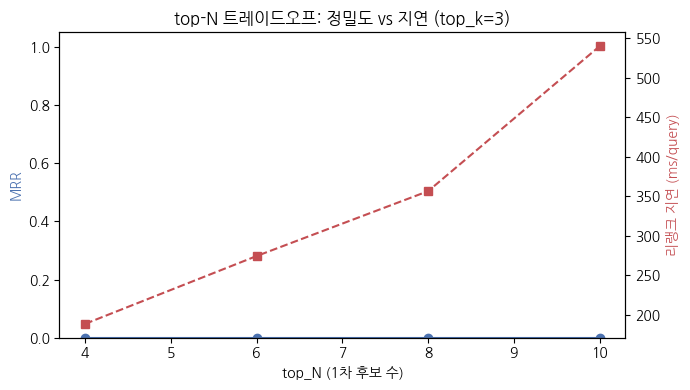

In [9]:
import matplotlib.pyplot as plt

# top_k=3 행만 골라 N 증가에 따른 MRR vs latency 트레이드오프
sub = df[df["top_k"] == 3].sort_values("top_N")
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sub["top_N"], sub["MRR"], "o-", color="#4C72B0", label="MRR")
ax1.set_xlabel("top_N (1차 후보 수)"); ax1.set_ylabel("MRR", color="#4C72B0"); ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.plot(sub["top_N"], sub["latency_ms/q"], "s--", color="#C44E52", label="latency")
ax2.set_ylabel("리랭크 지연 (ms/query)", color="#C44E52")
plt.title("top-N 트레이드오프: 정밀도 vs 지연 (top_k=3)")
fig.tight_layout(); plt.show()

> 해석: N을 키우면 정답을 놓칠 확률↓(MRR↑ 경향)이나 cross-encoder 호출이 늘어 지연↑

## Cross-Encoder vs Claude-rerank 비교
- Claude에게 질문-문서 관련도를 0~10으로 점수화시키는 **LLM 리랭커**를 만들고, cross-encoder와 top-k 품질을 비교
- Claude-rerank는 후보가 적을 때 근거·설명까지 얻을 수 있는 게 강점. 비용↑

### Cross-encoder vs Claude 리랭커 비교
- 이번엔 **Claude에게 후보들의 관련도를 0~10점**으로 매기게 해(LLM 리랭커) cross-encoder와 품질을 비교
- 이 부분에서 Claude 키가 쓰이고, 질문 수만큼 호출하므로 약간 시간/비용 발생
- **출력 읽는 법**: 세 줄(리랭크 없음/Cross-Encoder/Claude)의 MRR·nDCG를 비교
- 두 리랭커 모두 보통 '없음'보다 높음


In [10]:
# 리랭크 비교용 도구 정의 (client·MODEL은 맨 위 환경 셋업에서 준비됨)
SCORE_TOOL = [{
  "name": "score_docs",
  "description": "각 후보 문서의 질문 관련도를 0(무관)~10(완벽) 정수로 채점",
  "input_schema": {"type": "object", "properties": {
    "scores": {"type": "array", "items": {"type": "integer"},
               "description": "후보 순서대로의 0-10 관련도 점수 배열"}},
    "required": ["scores"]}
}]

def claude_rerank(query, cand_ids, top_k=TOP_K):
    listing = "\n".join(f"[{i}] {DOCS[cid]}" for i, cid in enumerate(cand_ids))
    msg = client.messages.create(model=MODEL, max_tokens=400, tools=SCORE_TOOL,
        tool_choice={"type": "tool", "name": "score_docs"},
        messages=[{"role": "user", "content":
            f"질문: {query}\n후보:\n{listing}\n각 후보의 관련도를 순서대로 0-10으로 채점하라."}])
    scores = None
    for b in msg.content:
        if b.type == "tool_use": scores = b.input["scores"]
    if not scores or len(scores) != len(cand_ids):
        return cand_ids[:top_k]  # 폴백
    ranked = [cid for cid, _ in sorted(zip(cand_ids, scores), key=lambda x: x[1], reverse=True)]
    return ranked[:top_k]

# 예상 호출: EVALSET 건수만큼 Claude 1회씩 (소규모)
def eval_reranker(rerank_fn):
    ms, ns = [], []
    for e in EVALSET:
        cand = hybrid_rank(e["q"], k=TOP_N)
        ranked = rerank_fn(e["q"], cand, TOP_K)
        ms.append(mrr(ranked, e["gold"])); ns.append(ndcg(ranked, e["gold"], TOP_K))
    return sum(ms)/len(ms), sum(ns)/len(ns)

m_ce, n_ce = eval_reranker(rerank)
m_cl, n_cl = eval_reranker(claude_rerank)
m_no, n_no = eval_pipe(False)
print(f"Hybrid-only      MRR={m_no:.3f}  nDCG={n_no:.3f}")
print(f"Cross-Encoder    MRR={m_ce:.3f}  nDCG={n_ce:.3f}")
print(f"Claude-rerank    MRR={m_cl:.3f}  nDCG={n_cl:.3f}")

Hybrid-only      MRR=0.000  nDCG=0.000
Cross-Encoder    MRR=0.000  nDCG=0.000
Claude-rerank    MRR=0.083  nDCG=0.125


### 세 방식 막대그래프 비교
- 리랭크 없음 vs Cross-Encoder vs Claude를 막대로 봄
- **그래프 읽는 법**: 두 리랭커 막대가 'Hybrid-only'보다 높으면 재정렬이 상위 정밀도를 올린 것
- Cross-Encoder는 싸고 빠름, Claude는 느리지만 근거 설명 가능


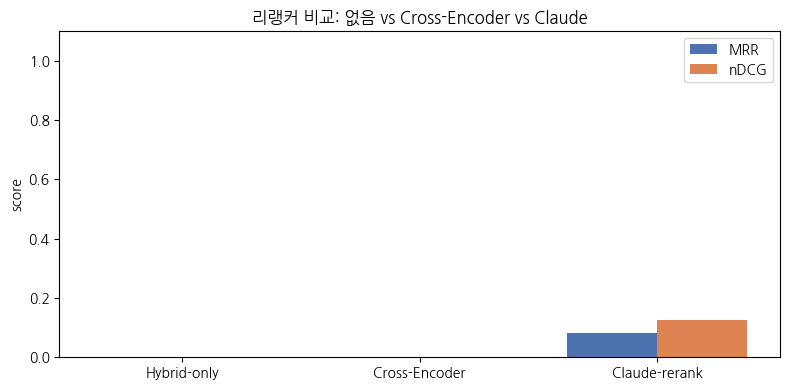

In [11]:
import numpy as np
labels = ["Hybrid-only", "Cross-Encoder", "Claude-rerank"]
mrrs  = [m_no, m_ce, m_cl]; ndcgs = [n_no, n_ce, n_cl]
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, mrrs,  w, label="MRR",  color="#4C72B0")
plt.bar(x + w/2, ndcgs, w, label="nDCG", color="#DD8452")
plt.xticks(x, labels); plt.ylim(0, 1.1); plt.ylabel("score")
plt.title("리랭커 비교: 없음 vs Cross-Encoder vs Claude")
plt.legend(); plt.tight_layout(); plt.show()

> 해석: 두 리랭커 모두 보통 Hybrid-only보다 상위 정밀도(MRR)를 올림  
Cross-Encoder는 빠르고 싸며, Claude-rerank는 느리지만 근거 설명을 덧붙일 수 있음

## 직접 해보기: Claude-rerank에 근거 받기
- `claude_rerank`를 확장해 점수와 함께 **선택 이유(reasoning)**도 받아 출력해 보기

In [12]:
# 직접 해보기: Claude 리랭커가 점수와 함께 '고른 이유'도 말하게 해보세요.
# 힌트: 도구 스키마에 reasoning을 추가하고, 반환할 때 이유를 함께 출력하면 됩니다(아래는 완성형).
SCORE_TOOL2 = [{
  "name": "score_docs",
  "description": "각 후보 문서의 질문 관련도를 0~10으로 채점하고 이유를 함께 보고",
  "input_schema": {"type": "object", "properties": {
    "reasoning": {"type": "string", "description": "왜 그렇게 점수를 줬는지"},
    "scores": {"type": "array", "items": {"type": "integer"}, "description": "후보 순서대로 0-10"}},
    "required": ["reasoning", "scores"]}
}]
def claude_rerank_explain(query, cand_ids, top_k=TOP_K):
    listing = "\n".join(f"[{i}] {DOCS[cid]}" for i, cid in enumerate(cand_ids))
    msg = client.messages.create(model=MODEL, max_tokens=500, tools=SCORE_TOOL2,
        tool_choice={"type": "tool", "name": "score_docs"},
        messages=[{"role": "user", "content": f"질문: {query}\n후보:\n{listing}\n각 후보의 관련도를 순서대로 0-10으로 채점하고, 그 점수를 매긴 이유를 'reasoning' 필드에 상세하게 설명하라."}]
    )
    out = next(b.input for b in msg.content if b.type == 'tool_use')

    reasoning_text = out.get('reasoning', '모델이 이유를 제공하지 않았습니다.')
    display_text = reasoning_text
    if len(reasoning_text) > 150:
        display_text = reasoning_text[:150] + '...'
    print('이유:', display_text)

    scores = out.get('scores')
    if scores is None or not isinstance(scores, list) or len(scores) != len(cand_ids):
        print("경고: 모델이 유효한 점수 목록을 제공하지 않았습니다. 원본 후보를 반환합니다.")
        return cand_ids[:top_k]

    ranked = [cid for cid, _ in sorted(zip(cand_ids, scores), key=lambda x: x[1], reverse=True)]
    return ranked[:top_k]
q0 = EVALSET[0]['q']
print('리랭크 결과:', claude_rerank_explain(q0, hybrid_rank(q0, TOP_N)))

이유: 모델이 이유를 제공하지 않았습니다.
경고: 모델이 유효한 점수 목록을 제공하지 않았습니다. 원본 후보를 반환합니다.
리랭크 결과: [8, 0, 2]


## 검증: 트레이드오프 표 & Claude-rerank

### 심화 부분 검증
- 트레이드오프 표가 채워졌는지, Claude 리랭커가 top-k 이하를 내는지, 두 리랭커가 'Hybrid-only'보다 나쁘지 않은지 확인
- `통과`면 정상


In [13]:
# 표가 비어있지 않고 latency가 0보다 큼
assert len(df) > 0 and (df["latency_ms/q"] >= 0).all()
# Claude-rerank가 top_k 이하를 반환
assert len(claude_rerank(EVALSET[0]["q"], hybrid_rank(EVALSET[0]["q"], TOP_N), TOP_K)) <= TOP_K
# 두 리랭커 모두 Hybrid-only 대비 MRR 악화 아님(동률 허용)
assert m_ce >= m_no - 1e-6 and m_cl >= m_no - 1e-6, "리랭크가 MRR을 악화시켜선 안 됨"
print("심화(트레이드오프/Claude-rerank) 검증 통과")

심화(트레이드오프/Claude-rerank) 검증 통과


## 확장과제
- **지연 예산 설계**: 위 트레이드오프 표에서 'MRR 손실 없이 가장 빠른 (N,k)'를 골라 SLA로 삼기
- **Cohere Rerank API**와 비교(키 필요): 상용 리랭커 대비 cross-encoder/Claude의 품질·비용
- **앙상블 리랭크**: cross-encoder 점수와 Claude 점수를 가중합해 더 안정적인 순위 만들기
- recall이 낮으면(1차에서 정답 누락) 리랭크로도 못 살림 → 검색 개선이 선행 (쿼리 재작성·HyDE 참고)